Preliminaries

In [1]:
import importlib
import coupling_utils as cl
import element
import numpy as np

importlib.reload(cl)
importlib.reload(element)

from element import get_matrix_element

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
import pandas as pd
import gc

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [4]:
m_t = 173

Checks

In [5]:
N = 10
X = torch.rand(N, 5, device=device, dtype=torch.float64)
(P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)
print(P.shape, P1.shape, P2.shape, P3.shape, jac_map.shape)


torch.Size([10, 4]) torch.Size([10, 4]) torch.Size([10, 4]) torch.Size([10, 4]) torch.Size([10])


In [6]:
element.check_conservation(P1, P2, P3, m_t, tol=1e-10)

Max |E1+E2+E3 - m_t|: 0.0
Max |p1+p2+p3|: 0.0
Conservation checks passed


In [7]:
me_values = element.batch_element_eval(P, P1, P2, P3, device=device, dtype=np.float64) * jac_map
print(me_values)

tensor([6.3072e+05, 2.3073e+03, 1.0706e+06, 1.6551e+05, 5.4733e+06, 1.3383e+06,
        8.4376e+04, 1.6459e+05, 6.1928e+06, 1.1915e+04], device='cuda:0',
       dtype=torch.float64)


Train flow

In [8]:
A_dims = [torch.tensor([1, 2, 3, 4]),
          torch.tensor([0, 2, 3, 4]),
          torch.tensor([0, 1, 3, 4]),
          torch.tensor([0, 1, 2, 3])]


B_dims = [torch.tensor([0]),
          torch.tensor([1]),
          torch.tensor([2]),
          torch.tensor([3]),
          torch.tensor([4])]

In [13]:
final_loss, loss_values, flow = cl.train_loop_decay(
    D=5,
    layer_type=cl.pwq_layer,
    A_dims=A_dims,
    B_dims=B_dims,
    K=64,
    hidden_size=16,
    N=5000,
    epochs=6000,
    lr=3e-5,
    device=device,
    dtype=np.float64,
    ticker=True
)

Normalisation scale: 21097357.789395496
Epoch: 0 | Loss: 9.09749332e-01
Mean value:  4344257.656830332
Epoch: 20 | Loss: 1.10858668e+00
Mean value:  4667218.685155081
Epoch: 40 | Loss: 7.35430478e-01
Mean value:  3991885.0248268023
Epoch: 60 | Loss: 9.68008784e-01
Mean value:  4490447.215796285
Epoch: 80 | Loss: 8.90700162e-01
Mean value:  4273443.223461818
Epoch: 100 | Loss: 9.67166025e-01
Mean value:  4348140.496422417
Epoch: 120 | Loss: 9.83912867e-01
Mean value:  4579472.756660872
Epoch: 140 | Loss: 9.86810843e-01
Mean value:  4773981.071089896
Epoch: 160 | Loss: 8.77541569e-01
Mean value:  4344299.967175624
Epoch: 180 | Loss: 8.62942967e-01
Mean value:  4265590.336058215
Epoch: 200 | Loss: 9.99594737e-01
Mean value:  4712315.830810403
Epoch: 220 | Loss: 1.01501684e+00
Mean value:  4753240.504497129
Epoch: 240 | Loss: 8.64546587e-01
Mean value:  4404710.112644389
Epoch: 260 | Loss: 7.83833879e-01
Mean value:  3872109.1114004594
Epoch: 280 | Loss: 9.18704141e-01
Mean value:  4679202

Plot loss behaviour

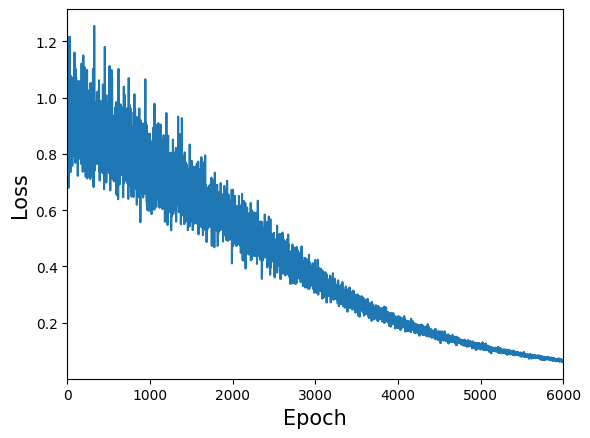

In [14]:
fig, ax = plt.subplots()

epochs_plot = torch.arange(len(loss_values))
ax.plot(epochs_plot, loss_values.cpu().numpy())

ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15)
ax.set_xlim(0, len(loss_values))

plt.show()

Estimate decay width and store parameters in CSV

In [19]:
def flow_decay_width_estimator(flow, B_total, chunk_size):

    flow = flow.to('cpu')
    flow.eval()

    prefactor = 1 / ((2*torch.pi)**5 * 16 * m_t)

    sum_w = torch.tensor(0.0, dtype=torch.float64)
    sum_w2 = torch.tensor(0.0, dtype=torch.float64)
    n_total = 0

    with torch.inference_mode():
        # optional one-off diagnostic check
        Y_test = torch.rand((1000, 5), device='cpu', dtype=torch.float64)
        X_test, _ = flow.inverse(Y_test)
        (_, P1t, P2t, P3t), _ = element.hypercube_to_momenta(X_test, m_t)
        element.check_conservation(P1t, P2t, P3t, m_t, tol=1e-10)
        del Y_test, X_test, P1t, P2t, P3t

        for i in range(0, B_total, chunk_size):
            b = min(chunk_size, B_total - i)

            Y = torch.rand((b, 5), device='cpu', dtype=torch.float64)
            X, jac_dets = flow.inverse(Y)

            (P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)
            me2_vals = element.batch_element_eval(P, P1, P2, P3, device='cpu', dtype=torch.float64)

            weights = prefactor * me2_vals * jac_dets * jac_map

            sum_w += weights.sum()
            sum_w2 += (weights * weights).sum()
            n_total += b

            del Y, X, jac_dets, P, P1, P2, P3, jac_map, me2_vals, weights

            if (i // chunk_size) % 10 == 0:
                gc.collect()

    mean = sum_w / n_total
    var = (sum_w2 / n_total) - mean**2
    stderr = torch.sqrt(var / n_total)

    return mean, stderr

In [20]:
def uniform_decay_width_estimator(B_total, chunk_size):
    
    prefactor = 1 / ((2*torch.pi)**5 * 16 * m_t)

    sum_w = torch.tensor(0.0, dtype=torch.float64)
    sum_w2 = torch.tensor(0.0, dtype=torch.float64)
    n_total = 0

    # optional one-off diagnostic check
    Y_test = torch.rand((1000, 5), device='cpu', dtype=torch.float64)
    X_test, _ = flow.inverse(Y_test)
    (_, P1t, P2t, P3t), _ = element.hypercube_to_momenta(X_test, m_t)
    element.check_conservation(P1t, P2t, P3t, m_t, tol=1e-10)
    del Y_test, X_test, P1t, P2t, P3t

    for i in range(0, B_total, chunk_size):
        b = min(chunk_size, B_total - i)

        X = torch.rand((b, 5), device='cpu', dtype=torch.float64)

        (P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)
        me2_vals = element.batch_element_eval(P, P1, P2, P3, device='cpu', dtype=torch.float64)

        weights = prefactor * me2_vals * jac_map

        sum_w += weights.sum()
        sum_w2 += (weights * weights).sum()
        n_total += b

        del X, P, P1, P2, P3, jac_map, me2_vals, weights

        if (i // chunk_size) % 10 == 0:
            gc.collect()

    mean = sum_w / n_total
    var = (sum_w2 / n_total) - mean**2
    stderr = torch.sqrt(var / n_total)

    return mean, stderr

In [ ]:
mean, stderr = flow_decay_width_estimator(flow, B_total=5000000, chunk_size=100000)

print(f"Flow-derived decay width estimate = {mean} ± {stderr}")

Max |E1+E2+E3 - m_t|: 2.842170943040401e-14
Max |p1+p2+p3|: 0.0
Conservation checks passed
Decay width estimate = 0.1557621102849405 ± 8.87554246887665e-05


In [21]:
mean_u, stderr_u = uniform_decay_width_estimator(B_total=5000000, chunk_size=100000)
print(f"Uniform-derived decay width estimate = {mean_u} ± {stderr_u}")

Max |E1+E2+E3 - m_t|: 2.842170943040401e-14
Max |p1+p2+p3|: 0.0
Conservation checks passed
Uniform-derived decay width estimate = 0.16407254746365746 ± 0.00033155184960991885


In [17]:
import pandas as pd
import os

def save_decay_result_pandas(filename, row_dict):
    df_row = pd.DataFrame([row_dict])

    if os.path.exists(filename):
        df_row.to_csv(filename, mode="a", header=False, index=False)
    else:
        df_row.to_csv(filename, index=False)

In [18]:
save_decay_result_pandas(
    "decay_width_results.csv",
    {
        "D": 5,
        "layer_type": "pwq_layer",
        "K": 64,
        "hidden_size": 16,
        "N": 5000,
        "epochs": 6000,
        "lr": 3e-5,
        "dtype": "float64",
        "B": 5000000,
        "final_loss": float(final_loss),
        "decay_width": float(mean),
        "decay_width_error": float(stderr),
    }
)

In [22]:
save_decay_result_pandas(
    "uniform_decay_width_results.csv",
    {
        "D": 5,
        "B": 5000000,
        "decay_width": float(mean_u),
        "decay_width_error": float(stderr_u),
    }
)